This shows the distibution of FiLM parameters , features before and after applying filM at early block 0 of finetuned best fold model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [3]:
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gc.enable()
import torch

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config

main_folder = "../../.."
data_csv    = os.path.join(main_folder, "data", "train.csv")
img_folder  = os.path.join(main_folder, "data", "train")

# EXPERIMENT-SPECIFIC
cfg_key  = "exp12_film"  # or other key
exp_name = "exp12_film_fusion_effB1_internal_early_modulation_finetune"
out_dir  = os.path.join(main_folder, "outputs", "extra", "exp12_film_fusion_effB1_internal_early_modulation_finetune")

df  = pd.read_csv(data_csv)
TARGET   = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

cfg = EXP_CONFIGS[cfg_key].copy()
cfg["name"] = exp_name

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Experiment:", cfg["name"])
print("Out dir:", out_dir)

Device: cuda
Experiment: exp12_film_fusion_effB1_internal_early_modulation_finetune
Out dir: ../../../outputs/extra/exp12_film_fusion_effB1_internal_early_modulation_finetune


In [4]:
oof_path = os.path.join(out_dir, "oof_detail.csv")
df_oof   = pd.read_csv(oof_path)

fold_rmse_list = []
for f in range(1, cfg["n_splits"] + 1):
    sub  = df_oof[df_oof.fold == f]
    rmse = ((sub.ytrue - sub.oof_pred) ** 2).mean() ** 0.5
    fold_rmse_list.append((f, rmse))
    print(f"Fold {f} OOF RMSE: {rmse:.4f} (n={len(sub)})")

best_fold, best_rmse = min(fold_rmse_list, key=lambda x: x[1])
print(f"\nBest fold: {best_fold} (OOF RMSE={best_rmse:.4f})")

Fold 1 OOF RMSE: 20.2943 (n=1983)
Fold 2 OOF RMSE: 20.1348 (n=1983)
Fold 3 OOF RMSE: 19.9016 (n=1982)
Fold 4 OOF RMSE: 20.4601 (n=1982)
Fold 5 OOF RMSE: 20.3550 (n=1982)

Best fold: 3 (OOF RMSE=19.9016)


In [5]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader
from src.data import build_transforms, ImageTabDataset

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
splits = list(kf.split(df))
tr_idx, val_idx = splits[best_fold - 1]

val_df = df.iloc[val_idx].reset_index(drop=True)
val_tf = build_transforms(cfg["img_size"], cfg["aug"], train=False)
val_ds = ImageTabDataset(val_df, img_folder, tab_cols, val_tf)

val_loader = DataLoader(
    val_ds, batch_size=32, shuffle=False,
    num_workers=16, pin_memory=True,
)

print("Val size (best fold):", len(val_ds))

Val size (best fold): 1982


In [6]:
from src.film import FiLMInternalModulation, FiLMExternalModulation

def build_best_model_internal(cfg, tab_cols, best_fold, out_dir, device):
    model = FiLMInternalModulation(
        backbone_name      = cfg["backbone"],
        img_size           = cfg["img_size"],
        tab_input_dim      = len(tab_cols),
        tab_hidden         = 64,
        film_start_idx     = 0,   # must match training (3 or 6 for mid/late)
        apply_to_all_after = False,
        head_hidden        = 256,
        pretrained         = False, #because weights are loaded from checkpoint
        use_bn_affine      = False, # False for finetune, True for frozen
        freeze_backbone    = False,   # False or True doesn't matter as gradients are off and weights are loaded from checkpoint
        tab_encoder_capacity = "small",
    )
    ckpt_path = os.path.join(out_dir, f"model_fold{best_fold}.pt")
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state)
    model.to(device).eval()
    print("Loaded:", ckpt_path)
    return model

analysis_model = build_best_model_internal(cfg, tab_cols, best_fold, out_dir, device)

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: ../../../outputs/extra/exp12_film_fusion_effB1_internal_early_modulation_finetune/model_fold3.pt


In [ ]:
from src.film_analysis import collect_film_stats

gamma, beta, feat_before, feat_after = collect_film_stats(
    analysis_model, val_loader, device, max_batches=None
)
print("FiLM blocks found:", sorted(gamma.keys()))

FiLM blocks found: [0]


so we are modulating the feature maps of block 0, which has 16 channel size, so our gamma and beta should also have the same size as we apply gamma and beta per channel, the change in size compared to EfficientNet (112x112) is due to our initial size of 256 instead of 224 due to architecture choice. since we mainly used 256 and 384 in our all experiments

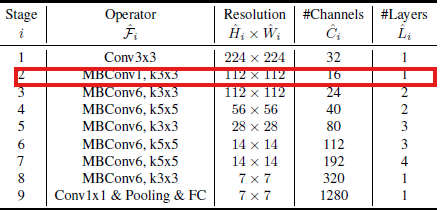


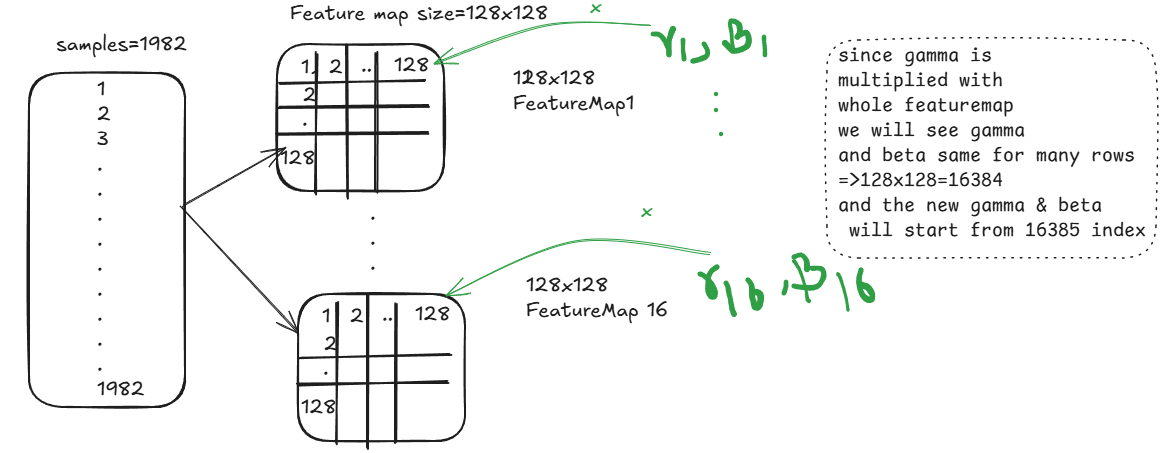


[Case A] Block 0  — exp12_film_fusion_effB1_internal_early_modulation_finetune
  gamma shape:       (1982, 16)
  beta shape:        (1982, 16)
  feat_before shape: (1982, 16, 128, 128)
  feat_after shape:  (1982, 16, 128, 128)


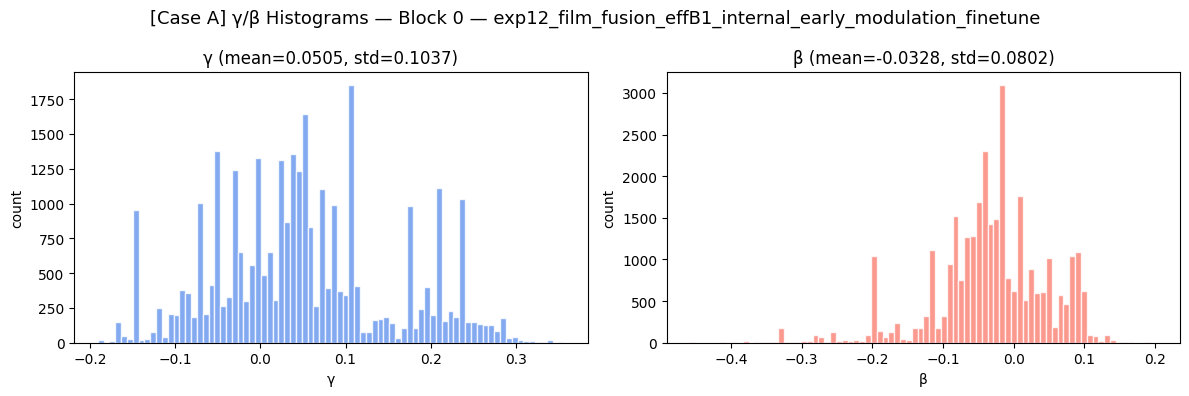

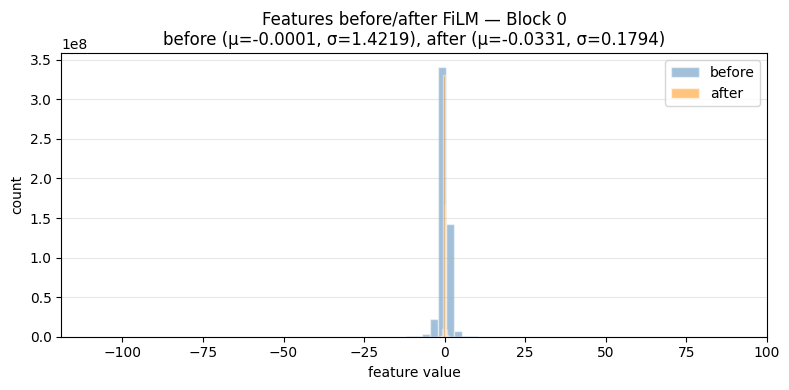

,block_idx,sample_idx,channel,h,w,before,after,gamma,beta,abs_diff
0,0,0,0,0,0,1.823699,0.035824,0.060197,-0.073958,1.787875
1,0,0,0,0,1,-0.145496,-0.082716,0.060197,-0.073958,0.062780
2,0,0,0,0,2,-0.001695,-0.074060,0.060197,-0.073958,0.072365
3,0,0,0,0,3,-0.050675,-0.077008,0.060197,-0.073958,0.026333
4,0,0,0,0,4,-0.045645,-0.076705,0.060197,-0.073958,0.031061
...,...,...,...,...,...,...,...,...,...,...
16380,0,0,0,127,124,1.893587,0.040031,0.060197,-0.073958,1.853556
16381,0,0,0,127,125,-0.461085,-0.101714,0.060197,-0.073958,0.359371
16382,0,0,0,127,126,-0.561856,-0.107780,0.060197,-0.073958,0.454076
16383,0,0,0,127,127,7.187510,0.358712,0.060197,-0.073958,6.828799


[Case A] Block 0 global stats:
  L2 ||after - before|| = 30451.4824


,block_idx,which,min,max,mean,std
0,0,before,-109.030334,90.149940,-0.000121,1.421946
1,0,after,-8.129117,20.158169,-0.033059,0.179393


In [ ]:
from src.film_analysis import case_A_per_block

case_A_per_block(
    gamma       = gamma,
    beta        = beta,
    feat_before = feat_before, #feature before FiLM 
    feat_after  = feat_after, # feature after FiLM 
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    n_table_rows = 16385, #to see the table with different gamma and beta, in other words featuremap 2
)


[Case A per-channel] Block 0 — exp12_film_fusion_effB1_internal_early_modulation_finetune
  feat_before shape: (1982, 16, 128, 128)
  feat_after  shape: (1982, 16, 128, 128)


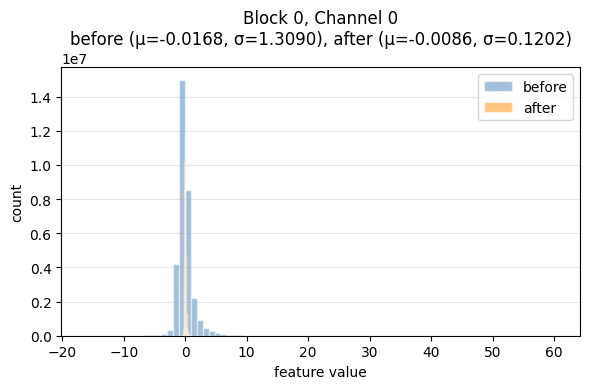

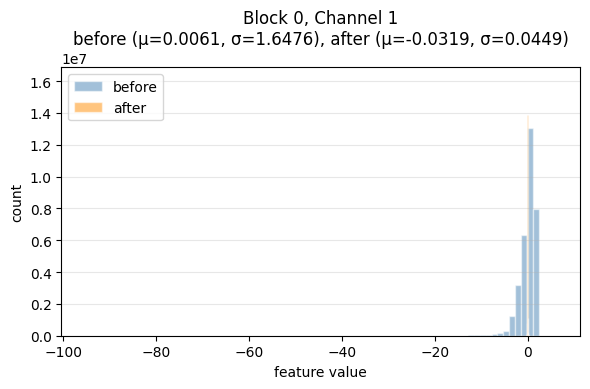

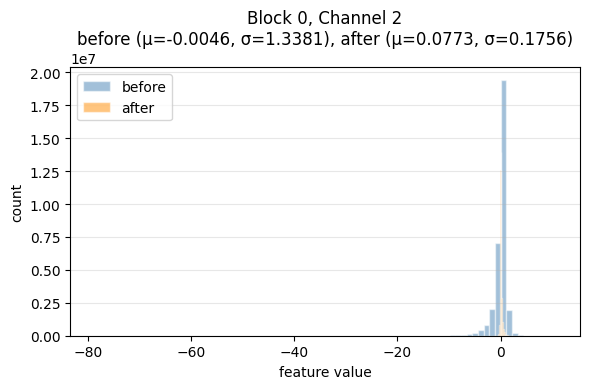

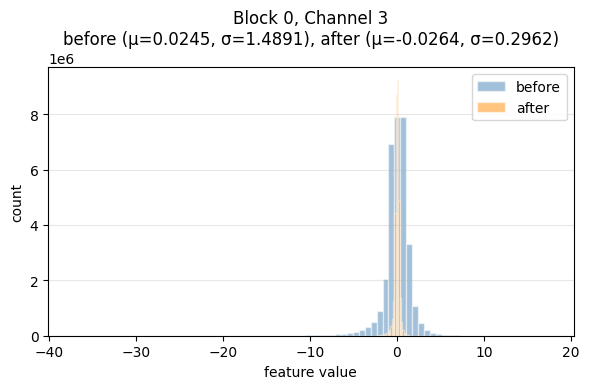

In [ ]:
from src.film_analysis import case_A_per_channel
case_A_per_channel(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_channels = 4,   # e.g. first 4 channels
)


[Case A per-sample] Block 0 — exp12_film_fusion_effB1_internal_early_modulation_finetune
  feat_before shape: (1982, 16, 128, 128)
  feat_after  shape: (1982, 16, 128, 128)


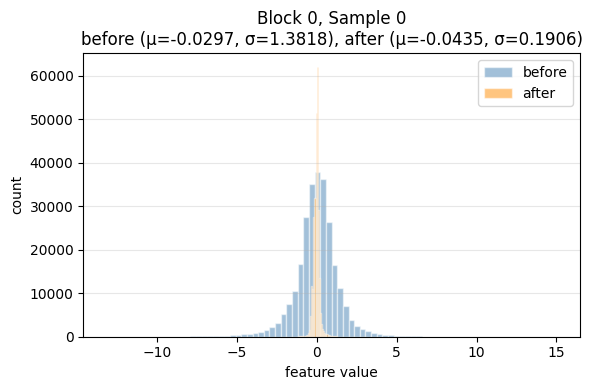

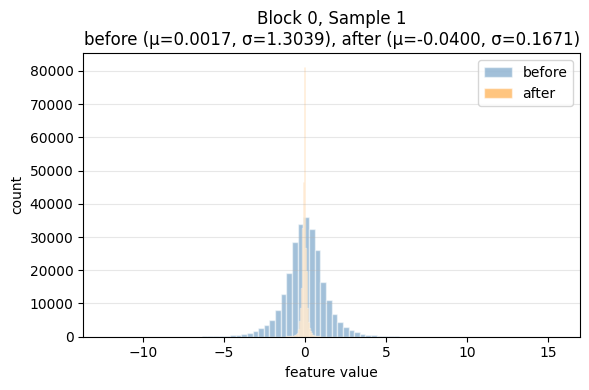

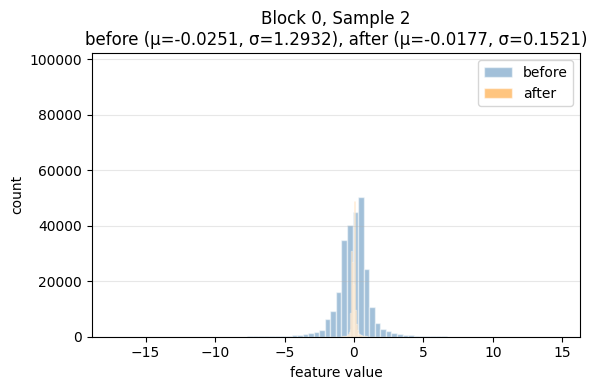

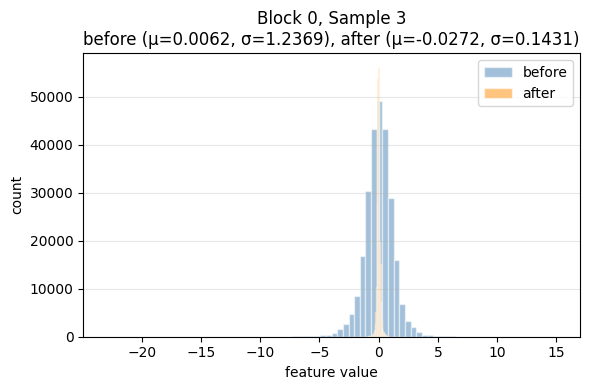

In [ ]:
from src.film_analysis import case_A_per_sample
case_A_per_sample(
    feat_before = feat_before,
    feat_after  = feat_after,
    exp_name    = cfg["name"],
    out_dir     = out_dir,
    max_samples = 4,   # e.g. first 4 samples
)